In [1]:
import json, os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import hashlib

In [2]:
plt.rcParams['figure.figsize'] = (8,5)

with_principles_path = 'ai_feedback_preferences_with_principles500.json'  
without_principles_path = 'ai_feedback_preferences_without_principles500.json'

print('WITH:', with_principles_path)
print('WITHOUT:', without_principles_path)

WITH: ai_feedback_preferences_with_principles500.json
WITHOUT: ai_feedback_preferences_without_principles500.json


In [ ]:
def _key_row(d):
    """Stable key from (prompt, A, B)."""
    tup = (d.get("prompt",""),
           d.get("A",""),
           d.get("B",""))
    return hashlib.sha1("||".join(tup).encode("utf-8")).hexdigest()

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    rows = []
    for r in data:
        rows.append({
            "key": _key_row(r),
            "prompt": (r.get("prompt","")),
            "A": (r.get("A","")),
            "B": (r.get("B","")),
            "label": r.get("label"),
            "principle": r.get("principle",""),
            "feedback_model": r.get("feedback_model",""),
            "judge_output": r.get("judge_output",""),
        })
    return pd.DataFrame(rows)

In [4]:
df_with = load_json(with_principles_path)
df_no   = load_json(without_principles_path)

In [5]:
merged_df = df_with.merge(
    df_no[["key","label","judge_output"]].rename(columns={
        "label":"label_no_principles",
        "judge_output":"judge_output_no_principles"
    }),
    on="key", how="inner"
).rename(columns={"label":"label_with_principles",
                  "judge_output":"judge_output_with_principles"})

In [6]:
merged_df.head()

,key,prompt,A,B,label_with_principles,principle,feedback_model,judge_output_with_principles,label_no_principles,judge_output_no_principles
0,563f05ad578ba2c21ef57b15fe2180be6e884339,do u know about nested genetic algorithm,"Yes, I am familiar with nested genetic algorit...","Yes, I'm familiar with nested genetic algorith...",A,Choose the answer that is longer.,TinyLlama/TinyLlama-1.1B-Chat-v1.0,,B,
1,04a8983367fd2fb3c5ba5c8a6930db1c24e4e126,Act as an intelligent being expert on computer...,"Sure, I can provide you with an overview of th...",Here's a general roadmap for developing a digi...,A,Choose the answer that uses more punctuation m...,TinyLlama/TinyLlama-1.1B-Chat-v1.0,,A,
2,177edb08796e36f6b19a34505f7b986c85d23dcf,Make a numbered list of 15 tips to maintain a ...,These useful suggestions can help you maintain...,"Sure, here are 15 tips to maintain a healthy w...",A,Choose the answer that is longer.,TinyLlama/TinyLlama-1.1B-Chat-v1.0,,A,
3,00106ef0669fa13e8d51bdfe09e2e6776bc7f419,You are a smart and experienced software engin...,"In the new microservices architecture, the sce...","In the microservices architecture, the new mod...",A,Choose the answer that uses more punctuation m...,TinyLlama/TinyLlama-1.1B-Chat-v1.0,,A,
4,f0df34cc287f954d2efc0b96bff8651cbbe0d047,"product description, dyson hand vacuum cleaner...",Job Title: Events Manager\n \n\n Location: Mel...,Job Title: Events Manager\n \n\n Location: Mel...,A,Choose the answer that uses more punctuation m...,TinyLlama/TinyLlama-1.1B-Chat-v1.0,,A,


Total shared items (by prompt+A+B): 500
  Matches:    410
  Mismatches: 90


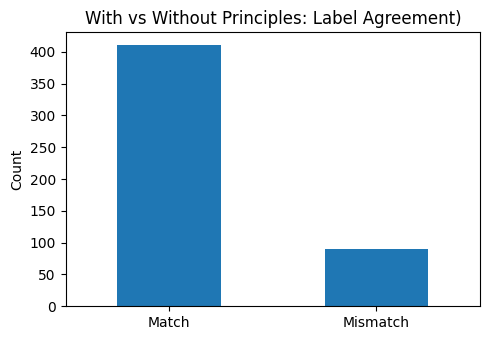

In [ ]:
merged_df["match"] = (merged_df["label_with_principles"] == merged_df["label_no_principles"])

total_pairs      = len(merged_df)
matches          = int(merged_df["match"].sum())
mismatches       = total_pairs - matches

print(f"Total shared items (by prompt+A+B): {len(merged_df)}")
print(f"  Matches:    {matches}")
print(f"  Mismatches: {mismatches}")

counts = pd.Series(
    {"Match": matches, "Mismatch": mismatches}
).sort_index()

plt.figure(figsize=(5,3.5))
counts.plot(kind="bar")
plt.title("With vs Without Principles: Label Agreement)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
PUNC_RE = re.compile(r'[,:;!\?\-]')
DIGIT_RE = re.compile(r'\d')

def pick_and_values(principle_text, r1, r2):
    pt = (principle_text or '').lower()
    r1 = r1 or ''
    r2 = r2 or ''

    if 'longer' in pt or 'length' in pt:
        v1, v2 = len(r1), len(r2)
        pick = 'A' if v1 >= v2 else 'B'
        return pick, 'length', v1, v2

    if ('punct' in pt) or ('punctuation' in pt):
        v1, v2 = len(PUNC_RE.findall(r1)), len(PUNC_RE.findall(r2))
        pick = 'A' if v1 >= v2 else 'B'
        return pick, 'punct', v1, v2

    if ('numer' in pt) or ('digit' in pt) or ('number' in pt):
        v1, v2 = len(DIGIT_RE.findall(r1)), len(DIGIT_RE.findall(r2))
        pick = 'A' if v1 >= v2 else 'B'
        return pick, 'digits', v1, v2

    return None, None, None, None

def evaluate_principle_accuracy(df):
    rows = []
    for _, r in merged_df.iterrows():
        r1 = r.get('A', '')
        r2 = r.get('B', '')
        principle = r.get('principle', '')

        pick, pkey, v1, v2 = pick_and_values(principle, r1, r2)
        if pick is None:
            continue

        rows.append({
            'principle': principle,
            'pkey': pkey,                               
            'label_with_principles': r.get('label_with_principles'),
            'label_no_principles': r.get('label_no_principles'),
            'text_analysis_pick': pick,
            'matched_principle': (pick == r.get('label_with_principles')),
            'no_principle_coincidence': (pick == r.get('label_no_principles')),
            'matched_w_and_wo_principles': (r.get('label_no_principles') == r.get('label_with_principles')),
            'full_match': (r.get('label_no_principles') == r.get('label_with_principles') == pick),
            'value_response_1': v1,                    
            'value_response_2': v2,                     
            'prompt': r.get('prompt'),
            'A': r1,
            'B': r2,
        })

    return pd.DataFrame(rows)

acc_df = evaluate_principle_accuracy(df_with)
print('Evaluated rows:', len(acc_df))
display(acc_df.head(10))

Evaluated rows: 500


,principle,pkey,label_with_principles,label_no_principles,text_analysis_pick,matched_principle,no_principle_coincidence,matched_w_and_wo_principles,full_match,value_response_1,value_response_2,prompt,A,B
0,Choose the answer that is longer.,length,A,B,B,False,True,False,False,1267,1680,do u know about nested genetic algorithm,"Yes, I am familiar with nested genetic algorit...","Yes, I'm familiar with nested genetic algorith..."
1,Choose the answer that uses more punctuation m...,punct,A,A,B,False,False,True,False,23,55,Act as an intelligent being expert on computer...,"Sure, I can provide you with an overview of th...",Here's a general roadmap for developing a digi...
2,Choose the answer that is longer.,length,A,A,B,False,False,True,False,3401,4316,Make a numbered list of 15 tips to maintain a ...,These useful suggestions can help you maintain...,"Sure, here are 15 tips to maintain a healthy w..."
3,Choose the answer that uses more punctuation m...,punct,A,A,A,True,True,True,True,19,3,You are a smart and experienced software engin...,"In the new microservices architecture, the sce...","In the microservices architecture, the new mod..."
4,Choose the answer that uses more punctuation m...,punct,A,A,B,False,False,True,False,43,51,"product description, dyson hand vacuum cleaner...",Job Title: Events Manager\n \n\n Location: Mel...,Job Title: Events Manager\n \n\n Location: Mel...
5,Choose the answer that is longer.,length,A,A,B,False,False,True,False,59,2981,what is jihad \n<extra_id_1>Assistant\njihad i...,China is committing genocide against the Uyghu...,China is accused of committing a range of huma...
6,Choose the answer that is longer.,length,A,A,B,False,False,True,False,312,2313,I'm dealing with the task of creating inquisit...,"Yes, the question is inquisitive. The question...",Here are the instructions you can provide to G...
7,Choose the answer that uses more punctuation m...,punct,A,A,B,False,False,True,False,5,24,Write an article in the style of the New York ...,Nancy Pelosi and Kamala Harris had a heated al...,Here is a possible article in the style of the...
8,Choose the answer that uses more numerical val...,digits,A,A,A,True,True,True,True,5,4,what are of scenarios and prospect of applying...,ChatGPT can be used in cultural ommersion in a...,ChatGPT can be used for cultural immersion as ...
9,Choose the answer that uses more numerical val...,digits,B,B,A,False,False,True,False,5,5,Name some ways in which different countries ca...,1. **Gross Domestic Product (GDP)**: This is ...,"There are many ways to compare countries, and ..."


,pkey,accuracy,n
0,longer,0.460123,163
1,numerical,0.611465,157
2,punctuation,0.411111,180


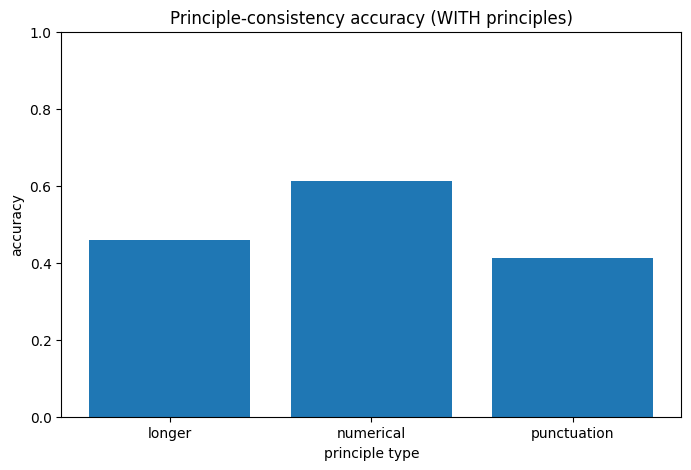

In [9]:
def norm_key(s):
    s = s.lower()
    if 'longer' in s: return 'longer'
    if 'punctuation' in s or 'comma' in s or 'semicolon' in s: return 'punctuation'
    if 'numerical' in s or 'number' in s or 'digit' in s: return 'numerical'
    return 'other'

acc_df['pkey'] = acc_df['principle'].apply(norm_key)
grp = acc_df.groupby('pkey')['matched_principle'].agg(['mean','count']).reset_index().rename(columns={'mean':'accuracy', 'count':'n'})
display(grp)

plt.figure()
plt.bar(grp['pkey'], grp['accuracy'])
plt.ylim(0,1)
plt.title('Principle-consistency accuracy (WITH principles)')
plt.ylabel('accuracy')
plt.xlabel('principle type')
plt.show()


,pkey,accuracy,n
0,longer,0.447853,163
1,numerical,0.643312,157
2,punctuation,0.394444,180


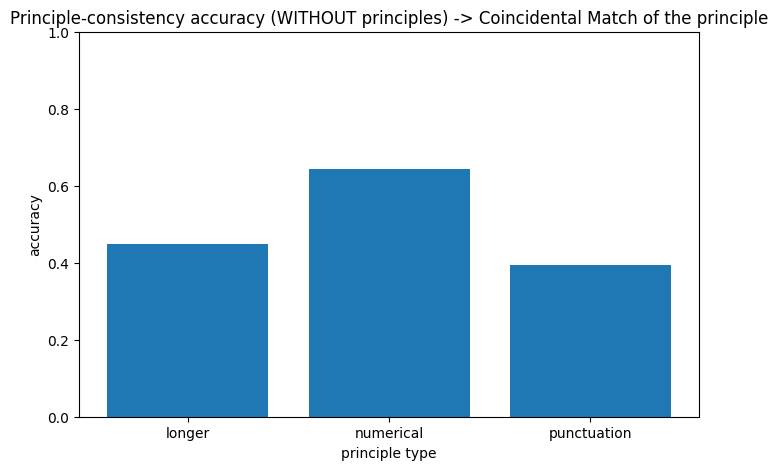

In [10]:
acc_df['pkey'] = acc_df['principle'].apply(norm_key)
grp = acc_df.groupby('pkey')['no_principle_coincidence'].agg(['mean','count']).reset_index().rename(columns={'mean':'accuracy', 'count':'n'})
display(grp)

plt.figure()
plt.bar(grp['pkey'], grp['accuracy'])
plt.ylim(0,1)
plt.title('Principle-consistency accuracy (WITHOUT principles) -> Coincidental Match of the principle')
plt.ylabel('accuracy')
plt.xlabel('principle type')
plt.show()

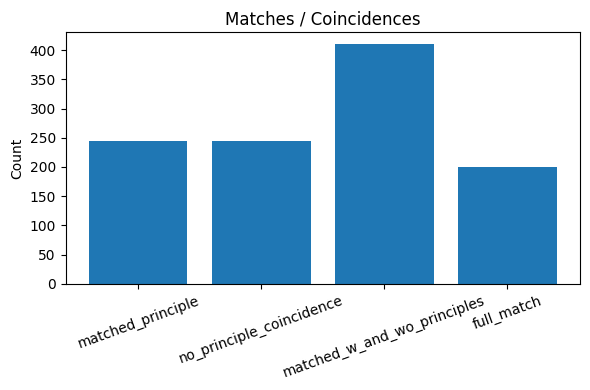

In [11]:
metrics = [
    "matched_principle",
    "no_principle_coincidence",
    "matched_w_and_wo_principles",
    "full_match"
]

counts = [acc_df[m].sum() for m in metrics]

plt.figure(figsize=(6,4))
plt.bar(metrics, counts)
plt.ylabel("Count")
plt.title("Matches / Coincidences")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()